# 04. Модели прогнозирования оттока

Ноутбук 03 определил этапы, на которых происходят потери. Настоящий ноутбук содержит построение инструмента, идентифицирующего конкретных учеников с повышенным риском, что позволяет подразделению продаж работать с приоритизированным списком, а не с базой целиком.

**Основное методологическое затруднение — утечка целевой информации.** Поведенческие признаки (`missed_classes`, `incomplete_hw`, рейтинг) агрегированы за весь первый курс, тогда как 76% повторных покупок совершаются до его завершения. Следовательно, для части наблюдений эти признаки описывают период, следующий за наступлением события, и модель, обученная на них без ограничений, использует информацию из будущего.

Решение состоит в фиксации момента прогноза и включении в модель исключительно тех данных, которые доступны на этот момент. Это определяет построение двух самостоятельных постановок задачи.

In [1]:
import sqlite3
from contextlib import closing

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.base import clone
from sklearn.calibration import calibration_curve
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (average_precision_score, brier_score_loss, precision_recall_curve,
                             roc_auc_score, roc_curve)
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier

DB_PATH = '../data/churn.db'
DATE_COLUMNS = ['first_course_start_date', 'first_course_end_date',
                'group_churn_date', 'second_course_payment_date']
RANDOM_STATE = 42
TEST_SIZE = 0.25

sns.set_theme(style='whitegrid', rc={'font.family': 'DejaVu Sans'})


def load_table(name):
    with closing(sqlite3.connect(DB_PATH)) as conn:
        frame = pd.read_sql_query(f'SELECT * FROM {name}', conn)
    for column in [c for c in DATE_COLUMNS if c in frame.columns]:
        frame[column] = pd.to_datetime(frame[column])
    return frame


df = load_table('model_input')
for column in ['dropped_out', 'bought_second', 'bought_before_course_end', 'rating_group_broken']:
    df[column] = df[column].astype(bool)

print(f'Загружено: {len(df):,} студентов (без индивидуального обучения)')

Загружено: 5,900 студентов (без индивидуального обучения)


## Анализ распределений признаков

Распределения исследуются для принятия решения о необходимости преобразований. Формальные критерии нормальности не применяются: ни логистическая регрессия, ни ансамбли деревьев не предполагают нормальности признаков — для регрессии существенна связь с логитом, деревья инвариантны к монотонным преобразованиям. Проверка гипотез, не влияющих на выбор модели, не проводится.

,mean,std,50%,min,max,асимметрия,эксцесс,дисперсия/среднее
age,10.74,2.48,11.00,5.0,17.0,0.22,-0.64,0.57
missed_classes,0.23,0.22,0.17,0.0,1.0,1.51,2.33,0.21
incomplete_hw,0.47,0.36,0.44,0.0,1.0,0.12,-1.44,0.28
rating_norm,0.51,0.36,0.50,0.0,1.0,0.01,-1.42,0.26
cs_tickets,21.98,36.72,13.00,0.0,648.0,6.55,66.72,61.35
course_duration_days,220.37,15.30,224.00,49.0,287.0,-10.34,112.86,1.06


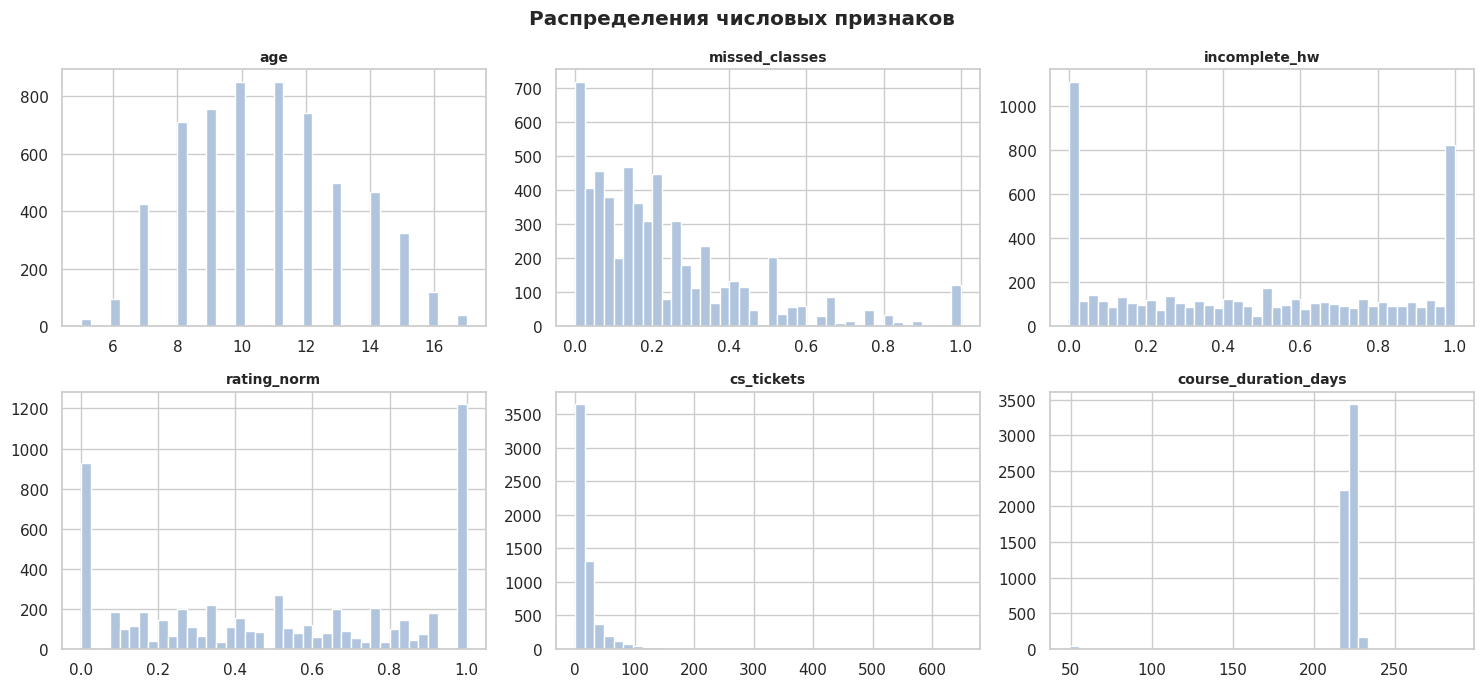

In [2]:
NUMERIC_CANDIDATES = ['age', 'missed_classes', 'incomplete_hw', 'rating_norm',
                      'cs_tickets', 'course_duration_days']

distribution = df[NUMERIC_CANDIDATES].describe().T[['mean', 'std', '50%', 'min', 'max']]
distribution['асимметрия'] = df[NUMERIC_CANDIDATES].skew()
distribution['эксцесс'] = df[NUMERIC_CANDIDATES].kurtosis()
distribution['дисперсия/среднее'] = df[NUMERIC_CANDIDATES].var() / df[NUMERIC_CANDIDATES].mean()

display(distribution.round(2))

fig, axes = plt.subplots(2, 3, figsize=(15, 7))
for axis, column in zip(axes.ravel(), NUMERIC_CANDIDATES):
    axis.hist(df[column], bins=40, color='lightsteelblue', edgecolor='white')
    axis.set_title(column, fontweight='bold', fontsize=10)
fig.suptitle('Распределения числовых признаков', fontweight='bold')
plt.tight_layout()
plt.show()

### Результаты анализа распределений

Признак `age` близок к симметричному (асимметрия 0.22), преобразований не требует.

Признак `missed_classes` смещён вправо (асимметрия 1.51): преобладают наблюдения с регулярным посещением, присутствует протяжённый правый хвост.

Признаки `incomplete_hw` и `rating_norm` характеризуются отрицательным эксцессом порядка −1.4, то есть распределения близки к равномерным. Для рейтинга это ожидаемо: нормировка на численность группы по построению распределяет значения по отрезку от нуля до единицы.

Признак `cs_tickets` представляет собой счётную переменную с экстремальным разбросом: асимметрия 6.55, эксцесс 66.7, отношение дисперсии к среднему 61. Для счётной величины это соответствует выраженной передисперсии, требующей преобразования перед включением в модель. Далее признак исключается по иным основаниям.

Признак `course_duration_days` сосредоточен около 224 дней с левым хвостом до 49 дней, соответствующим программам сокращённой длительности.

## Постановки задачи

In [3]:
CATEGORICAL_FEATURES = ['gender', 'course_group', 'utm_source_group',
                        'course_format_group', 'payment_type_group']

ENROLLMENT_NUMERIC = ['age']
COURSE_END_NUMERIC = ['age', 'missed_classes', 'incomplete_hw', 'rating_norm', 'course_duration_days']

ENROLLMENT_HORIZON = 240
POST_COURSE_HORIZON = 180

setup = pd.DataFrame([
    {
        'Модель': 'A. Риск на входе',
        'Момент прогноза': 'день зачисления',
        'Кто в выборке': 'вся когорта',
        'Целевая': f'покупка второго курса за {ENROLLMENT_HORIZON} дней от старта',
        'Признаки': 'только известные при первой продаже',
    },
    {
        'Модель': 'B. Кого дожимать после выпуска',
        'Момент прогноза': 'окончание первого курса',
        'Кто в выборке': 'кто ещё не купил к этому моменту',
        'Целевая': f'покупка за {POST_COURSE_HORIZON} дней после окончания курса',
        'Признаки': 'поведение за курс плюс анкетные',
    },
])

display(setup)

,Модель,Момент прогноза,Кто в выборке,Целевая,Признаки
0,A. Риск на входе,день зачисления,вся когорта,покупка второго курса за 240 дней от старта,только известные при первой продаже
1,B. Кого дожимать после выпуска,окончание первого курса,кто ещё не купил к этому моменту,покупка за 180 дней после окончания курса,поведение за курс плюс анкетные


## Модель A: оценка риска на момент зачисления

Момент прогноза — день зачисления. Доступны исключительно демографические и продуктовые характеристики: возраст, пол, канал привлечения, формат обучения, тип оплаты и курс. Поведенческие данные отсутствуют, поскольку обучение ещё не начато.

Горизонт целевой переменной — 240 дней от начала курса. Выполняется проверка на цензурирование: минимальная длительность наблюдения по когорте составляет 429 дней, следовательно, для каждого наблюдения период, достаточный для наступления события, обеспечен. Усечённые наблюдения отсутствуют.

In [4]:
enrollment = df.copy()
enrollment['target'] = enrollment['bought_second'] & (enrollment['days_to_second'] <= ENROLLMENT_HORIZON)

print(f'Модель A: {len(enrollment):,} студентов, '
      f'целевое событие у {enrollment["target"].mean() * 100:.1f}%')
print(f"Минимум наблюдения: {enrollment['observed_days'].min()} дней "
      f'(нужно {ENROLLMENT_HORIZON}) — цензурирования нет')

Модель A: 5,900 студентов, целевое событие у 27.0%
Минимум наблюдения: 429 дней (нужно 240) — цензурирования нет


## Модель B: оценка риска на момент завершения курса

Момент прогноза — завершение первого курса. В выборку включаются только ученики, не совершившие повторную покупку к этому моменту; для остальных событие уже наступило и прогнозирование лишено смысла.

Состав признаков включает поведенческие показатели за период обучения и демографические характеристики. На момент прогноза они известны полностью, целевое событие относится к последующему периоду, вследствие чего утечка целевой информации исключена.

Горизонт целевой переменной — 180 дней после завершения курса. Наблюдений, исключённых по недостаточной длительности периода наблюдения, не выявлено.

Следствием корректной постановки является сокращение выборки с 5 900 до 4 444 наблюдений и снижение доли целевого события с 27% до 7.6%. Классы существенно несбалансированы, в связи с чем оценка качества проводится не только по ROC-AUC, но и по PR-AUC.

In [5]:
post_course = df[~df['bought_before_course_end']].copy()
post_course['observed_after_end'] = post_course['observed_days'] - post_course['course_duration_days']

print(f'Не купили к концу курса: {len(post_course):,}')
short_observation = post_course['observed_after_end'] < POST_COURSE_HORIZON
print(f'Наблюдались после курса меньше {POST_COURSE_HORIZON} дней: {short_observation.sum()} — исключаем')

post_course = post_course[~short_observation].copy()
post_course['target'] = (post_course['bought_second']
                         & (post_course['days_after_course_end'] <= POST_COURSE_HORIZON))

print(f'Модель B: {len(post_course):,} студентов, '
      f'целевое событие у {post_course["target"].mean() * 100:.1f}%')

Не купили к концу курса: 4,444
Наблюдались после курса меньше 180 дней: 0 — исключаем
Модель B: 4,444 студентов, целевое событие у 7.6%


## Сравнение алгоритмов

Рассматриваются пять моделей на едином препроцессинге: стандартизация числовых признаков и one-hot кодирование категориальных.

Все преобразования включены в состав `Pipeline`, что принципиально для корректности оценки. Выполнение масштабирования и кодирования до разбиения выборки привело бы к использованию статистик всей выборки при обучении и, как следствие, к завышенной оценке качества. Внутри конвейера препроцессор обучается исключительно на тренировочном фолде.

In [6]:
def build_pipeline(model, numeric_features):
    preprocessor = ColumnTransformer([
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', drop='first', sparse_output=False), CATEGORICAL_FEATURES),
    ])
    return Pipeline([('prep', preprocessor), ('model', clone(model))])


CANDIDATES = {
    'Логистическая регрессия': LogisticRegression(max_iter=2000, random_state=RANDOM_STATE),
    'Логистическая с L1': LogisticRegression(max_iter=2000, penalty='l1', solver='liblinear',
                                             random_state=RANDOM_STATE),
    'Решающее дерево': DecisionTreeClassifier(max_depth=5, min_samples_leaf=50,
                                              random_state=RANDOM_STATE),
    'Случайный лес': RandomForestClassifier(n_estimators=400, min_samples_leaf=10,
                                            random_state=RANDOM_STATE, n_jobs=-1),
    'Градиентный бустинг': HistGradientBoostingClassifier(max_iter=300, learning_rate=0.05,
                                                          random_state=RANDOM_STATE),
}


def compare_models(frame, numeric_features, label):
    features = numeric_features + CATEGORICAL_FEATURES
    X, y = frame[features], frame['target']
    splitter = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

    rows = []
    for name, model in CANDIDATES.items():
        scores = cross_validate(build_pipeline(model, numeric_features), X, y, cv=splitter,
                                scoring=['roc_auc', 'average_precision'], n_jobs=-1)
        rows.append({
            'Модель': name,
            'ROC-AUC': scores['test_roc_auc'].mean(),
            'ROC-AUC ±': scores['test_roc_auc'].std(),
            'PR-AUC': scores['test_average_precision'].mean(),
        })

    result = pd.DataFrame(rows).sort_values('ROC-AUC', ascending=False).round(4).reset_index(drop=True)
    print(label)
    display(result)
    return result


enrollment_scores = compare_models(enrollment, ENROLLMENT_NUMERIC,
                                   'Модель A — риск на входе, кросс-валидация 5 фолдов')
post_course_scores = compare_models(post_course, COURSE_END_NUMERIC,
                                    'Модель B — после выпуска, кросс-валидация 5 фолдов')

Модель A — риск на входе, кросс-валидация 5 фолдов


,Модель,ROC-AUC,ROC-AUC ±,PR-AUC
0,Случайный лес,0.6757,0.0090,0.4361
1,Логистическая с L1,0.6735,0.0141,0.4216
2,Логистическая регрессия,0.6734,0.0142,0.4221
3,Решающее дерево,0.6635,0.0125,0.4063
4,Градиентный бустинг,0.6444,0.0135,0.3975


Модель B — после выпуска, кросс-валидация 5 фолдов


,Модель,ROC-AUC,ROC-AUC ±,PR-AUC
0,Случайный лес,0.7028,0.0213,0.1740
1,Логистическая с L1,0.6930,0.0261,0.1693
2,Логистическая регрессия,0.6884,0.0254,0.1662
3,Градиентный бустинг,0.6608,0.0246,0.1376
4,Решающее дерево,0.6607,0.0229,0.1426


### Различия между алгоритмами не превышают разброса по фолдам

Случайный лес демонстрирует наилучший результат в обеих постановках, однако преимущество незначительно: в модели A 0.6757 против 0.6734 у логистической регрессии при стандартном отклонении по фолдам 0.009; в модели B 0.7028 против 0.6884 при отклонении 0.021. Обе разницы находятся в пределах разброса.

Практическое следствие: выбор алгоритма в данной задаче не является определяющим. При внедрении модели в операционный регламент предпочтительна логистическая регрессия, обеспечивающая интерпретируемость коэффициентов при сопоставимом качестве. Дальнейшие расчёты выполнены на случайном лесе как на формальном лидере сравнения, однако данное решение может быть пересмотрено без потери качества.

Отдельно следует отметить результат градиентного бустинга (0.644 и 0.661). На выборке объёмом несколько тысяч наблюдений с преимущественно категориальными признаками преимущества метода не реализуются.

## Оценка на отложенной выборке

In [7]:
def evaluate_holdout(frame, numeric_features, model_name, label):
    features = numeric_features + CATEGORICAL_FEATURES
    X_train, X_test, y_train, y_test = train_test_split(
        frame[features], frame['target'], test_size=TEST_SIZE,
        stratify=frame['target'], random_state=RANDOM_STATE)

    pipeline = build_pipeline(CANDIDATES[model_name], numeric_features).fit(X_train, y_train)
    probabilities = pipeline.predict_proba(X_test)[:, 1]

    metrics = {
        'Модель': label,
        'Алгоритм': model_name,
        'Обучение / тест': f'{len(X_train):,} / {len(X_test):,}',
        'ROC-AUC': round(roc_auc_score(y_test, probabilities), 4),
        'PR-AUC': round(average_precision_score(y_test, probabilities), 4),
        'Brier': round(brier_score_loss(y_test, probabilities), 4),
        'Базовая доля события': round(y_test.mean(), 4),
    }
    return metrics, pipeline, y_test, probabilities


best_enrollment = enrollment_scores.loc[0, 'Модель']
best_post_course = post_course_scores.loc[0, 'Модель']

metrics_a, pipeline_a, y_test_a, proba_a = evaluate_holdout(
    enrollment, ENROLLMENT_NUMERIC, best_enrollment, 'A. Риск на входе')
metrics_b, pipeline_b, y_test_b, proba_b = evaluate_holdout(
    post_course, COURSE_END_NUMERIC, best_post_course, 'B. После выпуска')

display(pd.DataFrame([metrics_a, metrics_b]))

,Модель,Алгоритм,Обучение / тест,ROC-AUC,PR-AUC,Brier,Базовая доля события
0,A. Риск на входе,Случайный лес,"4,425 / 1,475",0.6722,0.4391,0.1824,0.2698
1,B. После выпуска,Случайный лес,"3,333 / 1,111",0.7023,0.1497,0.0674,0.0756


### Сопоставление качества моделей

Значение ROC-AUC составляет 0.672 для модели на момент зачисления и 0.702 для модели на момент завершения курса. Прямое сравнение показателей некорректно вследствие различий в составе выборок и базовой доле целевого события.

Более информативен показатель PR-AUC. Для модели A он составляет 0.439 при базовой доле 27%, что в 1.6 раза превышает уровень случайного ранжирования. Для модели B — 0.150 при базовой доле 7.6%, что соответствует практически двукратному превышению. Обе модели работоспособны, при этом модель B решает более сложную задачу: выявление редких покупок в аудитории с высоким риском оттока.

Меньшее значение метрики Бриера у модели B (0.067 против 0.182) обусловлено более низкой частотой события и не свидетельствует о более высоком качестве.

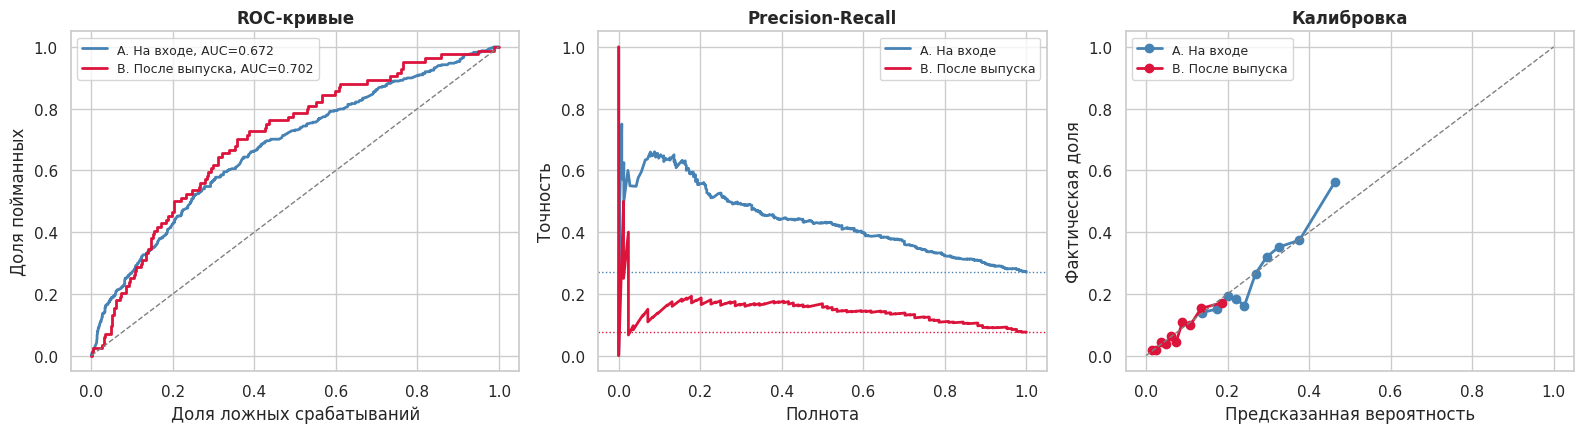

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

for label, y_true, probabilities, color in [('A. На входе', y_test_a, proba_a, 'steelblue'),
                                            ('B. После выпуска', y_test_b, proba_b, 'crimson')]:
    fpr, tpr, _ = roc_curve(y_true, probabilities)
    axes[0].plot(fpr, tpr, color=color, linewidth=2,
                 label=f'{label}, AUC={roc_auc_score(y_true, probabilities):.3f}')

    precision, recall, _ = precision_recall_curve(y_true, probabilities)
    axes[1].plot(recall, precision, color=color, linewidth=2, label=label)
    axes[1].axhline(y_true.mean(), color=color, linestyle=':', linewidth=1)

    observed, predicted = calibration_curve(y_true, probabilities, n_bins=10, strategy='quantile')
    axes[2].plot(predicted, observed, marker='o', color=color, linewidth=2, label=label)

axes[0].plot([0, 1], [0, 1], color='grey', linestyle='--', linewidth=1)
axes[0].set_title('ROC-кривые', fontweight='bold')
axes[0].set_xlabel('Доля ложных срабатываний')
axes[0].set_ylabel('Доля пойманных')
axes[0].legend(fontsize=9)

axes[1].set_title('Precision-Recall', fontweight='bold')
axes[1].set_xlabel('Полнота')
axes[1].set_ylabel('Точность')
axes[1].legend(fontsize=9)

axes[2].plot([0, 1], [0, 1], color='grey', linestyle='--', linewidth=1)
axes[2].set_title('Калибровка', fontweight='bold')
axes[2].set_xlabel('Предсказанная вероятность')
axes[2].set_ylabel('Фактическая доля')
axes[2].legend(fontsize=9)

plt.tight_layout()
plt.show()

## Приоритизация клиентской базы

Для операционного применения существенна не общая точность модели, а ответ на прикладной вопрос: при обработке N% базы какая доля будущих покупок будет охвачена.

Тестовая выборка разбивается на десять групп по убыванию прогнозируемого риска.

In [9]:
def lift_by_decile(y_true, probabilities, label):
    frame = pd.DataFrame({'y': np.asarray(y_true), 'p': probabilities})
    frame['decile'] = pd.qcut(frame['p'].rank(method='first', ascending=False), 10,
                              labels=range(1, 11)).astype(int)

    base_rate = frame['y'].mean()
    table = frame.groupby('decile').agg(students=('y', 'size'), events=('y', 'sum'))
    table['доля события, %'] = (table['events'] / table['students'] * 100).round(1)
    table['lift'] = (table['events'] / table['students'] / base_rate).round(2)
    table['накопленная полнота, %'] = (table['events'].cumsum() / frame['y'].sum() * 100).round(1)

    print(f'{label}: базовая доля события {base_rate * 100:.1f}%')
    display(table.reset_index())
    return table


lift_a = lift_by_decile(y_test_a, proba_a, 'Модель A')
lift_b = lift_by_decile(y_test_b, proba_b, 'Модель B')

Модель A: базовая доля события 27.0%


,decile,students,events,"доля события, %",lift,"накопленная полнота, %"
0,1,148,83,56.1,2.08,20.9
1,2,147,55,37.4,1.39,34.7
2,3,148,52,35.1,1.30,47.7
3,4,147,47,32.0,1.18,59.5
4,5,148,39,26.4,0.98,69.3
5,6,147,24,16.3,0.61,75.4
6,7,147,27,18.4,0.68,82.2
7,8,148,29,19.6,0.73,89.4
8,9,147,21,14.3,0.53,94.7
9,10,148,21,14.2,0.53,100.0


Модель B: базовая доля события 7.6%


,decile,students,events,"доля события, %",lift,"накопленная полнота, %"
0,1,112,19,17.0,2.24,22.6
1,2,111,17,15.3,2.03,42.9
2,3,111,12,10.8,1.43,57.1
3,4,111,11,9.9,1.31,70.2
4,5,111,5,4.5,0.60,76.2
5,6,111,7,6.3,0.83,84.5
6,7,111,4,3.6,0.48,89.3
7,8,111,5,4.5,0.60,95.2
8,9,111,2,1.8,0.24,97.6
9,10,111,2,1.8,0.24,100.0


### Результаты приоритизации

**Модель A.** В верхнем дециле конверсия составляет 56.1% против базовых 27.0%, что соответствует лифту 2.08. Первые три дециля обеспечивают охват 47.7% всех покупок: при обработке 30% базы охватывается почти половина будущих клиентов.

**Модель B.** В верхнем дециле конверсия составляет 17.0% против базовых 7.6%, лифт 2.24. Первые три дециля обеспечивают охват 57.1% поздних покупок.

Практическая ценность заключается в переходе от равномерной обработки базы к работе с третью её объёма при потере половины, а не всего результата.

## Значимость признаков

In [10]:
def coefficient_table(pipeline, numeric_features, top=15):
    encoder = pipeline.named_steps['prep'].named_transformers_['cat']
    names = numeric_features + list(encoder.get_feature_names_out(CATEGORICAL_FEATURES))
    model = pipeline.named_steps['model']

    if hasattr(model, 'coef_'):
        values = pd.Series(model.coef_[0], index=names, name='коэффициент')
        return values.reindex(values.abs().sort_values(ascending=False).index).head(top).to_frame().round(3)
    return None


def importance_table(pipeline, frame, numeric_features, top=15):
    features = numeric_features + CATEGORICAL_FEATURES
    X_train, X_test, y_train, y_test = train_test_split(
        frame[features], frame['target'], test_size=TEST_SIZE,
        stratify=frame['target'], random_state=RANDOM_STATE)

    result = permutation_importance(pipeline, X_test, y_test, n_repeats=10,
                                    random_state=RANDOM_STATE, scoring='roc_auc', n_jobs=-1)
    return (pd.Series(result.importances_mean, index=features, name='падение ROC-AUC')
            .sort_values(ascending=False).head(top).to_frame().round(4))


for label, pipeline, frame, numeric_features in [
        ('Модель A', pipeline_a, enrollment, ENROLLMENT_NUMERIC),
        ('Модель B', pipeline_b, post_course, COURSE_END_NUMERIC)]:
    print(label)
    coefficients = coefficient_table(pipeline, numeric_features)
    if coefficients is not None:
        display(coefficients)
    display(importance_table(pipeline, frame, numeric_features))

Модель A


,падение ROC-AUC
payment_type_group,0.1240
age,0.0139
course_group,0.0116
utm_source_group,0.0090
gender,0.0038
course_format_group,0.0013


Модель B


,падение ROC-AUC
rating_norm,0.0566
missed_classes,0.0331
course_duration_days,0.0148
incomplete_hw,0.0077
age,0.0074
gender,0.0067
payment_type_group,0.0063
course_group,0.0037
utm_source_group,0.0016
course_format_group,-0.0023


### Определяющие факторы различаются по моменту прогноза

**Модель A.** Со значительным отрывом лидирует тип оплаты: снижение ROC-AUC при перестановке значений составляет 0.124 против 0.014 у возраста. Вклад остальных признаков — курса, канала привлечения, пола, формата — близок к нулю. Таким образом, на момент зачисления единственный существенный сигнал о будущем удержании содержится в схеме оплаты, что согласуется с результатами сегментного анализа в ноутбуке 03.

**Модель B.** Лидирующим предиктором выступает нормированный рейтинг (0.057), далее следует доля пропущенных занятий (0.033). Данный результат обосновывает процедуру нормировки, выполненную в ноутбуке 02: без приведения ранга к численности группы признак оставался бы несопоставимым между форматами и такого вклада не обеспечил.

Показатели успеваемости и посещаемости оказываются информативнее демографических характеристик, однако становятся доступны только к моменту завершения курса.

## Проверка на утечку целевой информации

In [11]:
def quick_auc(frame, numeric_features, model_name=None):
    features = numeric_features + CATEGORICAL_FEATURES
    X_train, X_test, y_train, y_test = train_test_split(
        frame[features], frame['target'], test_size=TEST_SIZE,
        stratify=frame['target'], random_state=RANDOM_STATE)
    model = CANDIDATES[model_name or best_post_course]
    pipeline = build_pipeline(model, numeric_features).fit(X_train, y_train)
    return roc_auc_score(y_test, pipeline.predict_proba(X_test)[:, 1])


leakage_check = pd.DataFrame([
    {'Набор признаков': 'без cs_tickets (основной)',
     'ROC-AUC': round(quick_auc(post_course, COURSE_END_NUMERIC), 4)},
    {'Набор признаков': 'с cs_tickets',
     'ROC-AUC': round(quick_auc(post_course, COURSE_END_NUMERIC + ['cs_tickets']), 4)},
])

display(leakage_check)

tickets_effect = post_course.assign(
    bucket=pd.qcut(post_course['cs_tickets'], 4, duplicates='drop')
).groupby('bucket', observed=True)['target'].agg(students='size', event_rate='mean')
tickets_effect['доля события, %'] = (tickets_effect['event_rate'] * 100).round(1)

display(tickets_effect.drop(columns='event_rate'))

,Набор признаков,ROC-AUC
0,без cs_tickets (основной),0.7023
1,с cs_tickets,0.7352


,students,"доля события, %"
bucket,,
"(-0.001, 5.0]",1215,4.9
"(5.0, 11.0]",1160,7.2
"(11.0, 18.0]",982,8.0
"(18.0, 328.0]",1087,10.7


### Обоснование исключения признака `cs_tickets`

Включение признака повышает ROC-AUC с 0.702 до 0.735. Прирост в три пункта за счёт одного признака сам по себе требует проверки.

Приведённая ниже таблица показывает, что в выборке модели B связь выражена существенно слабее, чем по когорте в целом: 4.9% в нижней квартили против 10.7% в верхней, различие немногим более двукратного. По всей когорте различие достигало трёх с половиной раз.

Такое поведение характерно для признака, накопленного за весь период наблюдения: чем дольше клиент остаётся в продукте, тем большее число обращений фиксируется, вследствие чего показатель измеряет длительность жизненного цикла, а не поведение. Проверка данного предположения по имеющимся данным невозможна — даты обращений в выгрузке отсутствуют.

На основании изложенного признак исключён из основных моделей, а в требования к последующей выгрузке включён пункт о предоставлении обращений с датами, что позволит ограничить признак моментом прогноза.

## Проверка устойчивости

In [12]:
robustness = []

clean_groups = post_course[~post_course['rating_group_broken']]
robustness.append({
    'Проверка': 'без групп со сломанным рейтингом',
    'Студентов': len(clean_groups),
    'ROC-AUC': round(quick_auc(clean_groups, COURSE_END_NUMERIC), 4),
})

features = COURSE_END_NUMERIC + CATEGORICAL_FEATURES
time_split = post_course['first_course_start_date'].dt.month <= 9
pipeline = build_pipeline(CANDIDATES[best_post_course], COURSE_END_NUMERIC).fit(
    post_course.loc[time_split, features], post_course.loc[time_split, 'target'])
time_auc = roc_auc_score(post_course.loc[~time_split, 'target'],
                         pipeline.predict_proba(post_course.loc[~time_split, features])[:, 1])

robustness.append({
    'Проверка': 'обучение на когортах январь-сентябрь, тест на октябре-декабре',
    'Студентов': int((~time_split).sum()),
    'ROC-AUC': round(time_auc, 4),
})

robustness.append({
    'Проверка': 'случайное разбиение (базовое)',
    'Студентов': int(len(post_course) * TEST_SIZE),
    'ROC-AUC': metrics_b['ROC-AUC'],
})

display(pd.DataFrame(robustness))

,Проверка,Студентов,ROC-AUC
0,без групп со сломанным рейтингом,3602,0.7456
1,"обучение на когортах январь-сентябрь, тест на ...",1298,0.7051
2,случайное разбиение (базовое),1111,0.7023


### Результаты проверки устойчивости

Выполнены три проверки:

- **Исключение групп с некорректным рейтингом** даёт ROC-AUC 0.746 на 3 602 наблюдениях против 0.702 на полной выборке. Прямое сравнение этих значений некорректно: выборки различаются по составу и объёму. Существенно то, что качество не снижается — результаты не обусловлены группами с недостижимыми рангами.
- **Обучение на когортах января–сентября с проверкой на когортах октября–декабря** обеспечивает 0.705, что практически соответствует результату при случайном разбиении. Модель сохраняет качество на последующих когортах несмотря на снижение конверсии в течение года.
- **Случайное разбиение** — 0.702, базовый вариант.

## Выводы

1. **Использованы две постановки задачи вместо одной.** Модель на момент зачисления работает с демографическими данными и обеспечивает оценку риска с первого дня. Модель на момент завершения курса использует поведенческие признаки и обладает более высокой точностью, однако применяется тогда, когда вероятность повторной покупки уже составляет порядка 10%.
2. **Выбор алгоритма не является определяющим.** Различие между логистической регрессией и случайным лесом не превышает разброса по фолдам кросс-валидации. При внедрении приоритет имеет интерпретируемость.
3. **Приоритизация работоспособна.** Верхний дециль риска обеспечивает двукратный лифт в обеих моделях, треть базы охватывает от 47.7% до 57.1% будущих покупок на отложенной выборке.
4. **Определяющие факторы различаются по моменту прогноза:** на входе — тип оплаты, после завершения курса — рейтинг и посещаемость.
5. **Признак обращений в поддержку исключён** как вероятный источник утечки целевой информации. Проверить предположение напрямую нельзя: даты обращений в выгрузке отсутствуют.